In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/heart_disease_uci.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (920, 16)

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
df_clean = df.copy()

# Drop useless columns
df_clean = df_clean.drop(columns=['id', 'dataset'])

print("Remaining columns:")
print(df_clean.columns.tolist())
print("\nShape:", df_clean.shape)

Remaining columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Shape: (920, 14)


In [5]:
df_clean['num'] = df_clean['num'].apply(lambda x: 1 if x > 0 else 0)

print("Target Distribution:")
print(df_clean['num'].value_counts())

Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [6]:
print("Missing Values:")
print(df_clean.isnull().sum())

Missing Values:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [7]:
# Fill ca with median per group
df_clean['ca'] = df_clean.groupby('num')['ca'].transform(
    lambda x: x.fillna(x.median())
)

# Fill thal with mode per group
df_clean['thal'] = df_clean.groupby('num')['thal'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print("Missing after fixing ca and thal:")
print(df_clean[['ca', 'thal']].isnull().sum())

Missing after fixing ca and thal:
ca      0
thal    0
dtype: int64


In [8]:
# Fill numeric columns with median
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns with mode
cat_cols = ['fbs', 'restecg', 'exang', 'slope']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

Missing Values After Cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [9]:
print("Shape:", df_clean.shape)
print("\nData Types:")
print(df_clean.dtypes)
print("\nTarget Distribution:")
print(df_clean['num'].value_counts())

Shape: (920, 14)

Data Types:
age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [10]:
# Sex: Male=1, Female=0
df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})

# fbs and exang: True=1, False=0
df_clean['fbs'] = df_clean['fbs'].astype(int)
df_clean['exang'] = df_clean['exang'].astype(int)

print("Binary columns encoded:")
print(df_clean[['sex', 'fbs', 'exang']].head())

Binary columns encoded:
   sex  fbs  exang
0    1    1      0
1    1    0      1
2    1    0      1
3    1    0      0
4    0    0      0


In [11]:
# One hot encode categorical columns
cat_cols = ['cp', 'restecg', 'slope', 'thal']
df_clean = pd.get_dummies(df_clean, columns=cat_cols)

print("Shape after encoding:", df_clean.shape)
print("\nNew columns:")
print(df_clean.columns.tolist())

Shape after encoding: (920, 23)

New columns:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'num', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


In [12]:
print("Shape:", df_clean.shape)
print("\nMissing Values:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows:")
df_clean.head()

Shape: (920, 23)

Missing Values:
age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
num                         0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
dtype: int64

First 5 rows:


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,...,True,True,False,False,True,False,False,True,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,...,False,True,False,False,False,True,False,False,True,False
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,...,False,True,False,False,False,True,False,False,False,True
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,...,False,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,...,False,True,False,False,False,False,True,False,True,False


In [19]:
# Convert True/False to 1/0
df_clean = df_clean.astype({col: int for col in df_clean.select_dtypes(bool).columns})

print("Data Types:")
print(df_clean.dtypes)

Data Types:
age                           int64
sex                           int64
trestbps                    float64
chol                        float64
fbs                           int64
thalch                      float64
exang                         int64
oldpeak                     float64
ca                          float64
num                           int64
cp_asymptomatic               int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_lv hypertrophy        int64
restecg_normal                int64
restecg_st-t abnormality      int64
slope_downsloping             int64
slope_flat                    int64
slope_upsloping               int64
thal_fixed defect             int64
thal_normal                   int64
thal_reversable defect        int64
dtype: object


In [20]:
df_clean.to_csv('../data/heart_clean.csv', index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


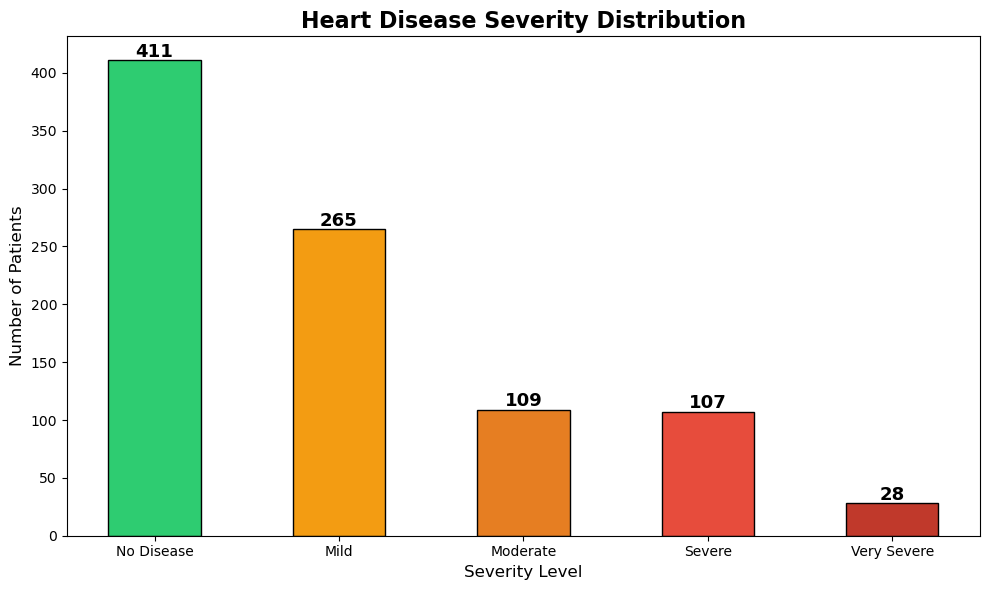

In [20]:
plt.figure(figsize=(10, 6))

severity = df['num'].value_counts().sort_index()
colors = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C', '#C0392B']
labels = ['No Disease', 'Mild', 'Moderate', 'Severe', 'Very Severe']

bars = plt.bar(labels, severity.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, severity.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{val}', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Severity Distribution',
          fontsize=16, fontweight='bold')
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/hd_01_disease_count.png', dpi=150)
plt.show()

In [22]:
# Convert num to binary first
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print("Target Distribution:")
print(df['num'].value_counts())

Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


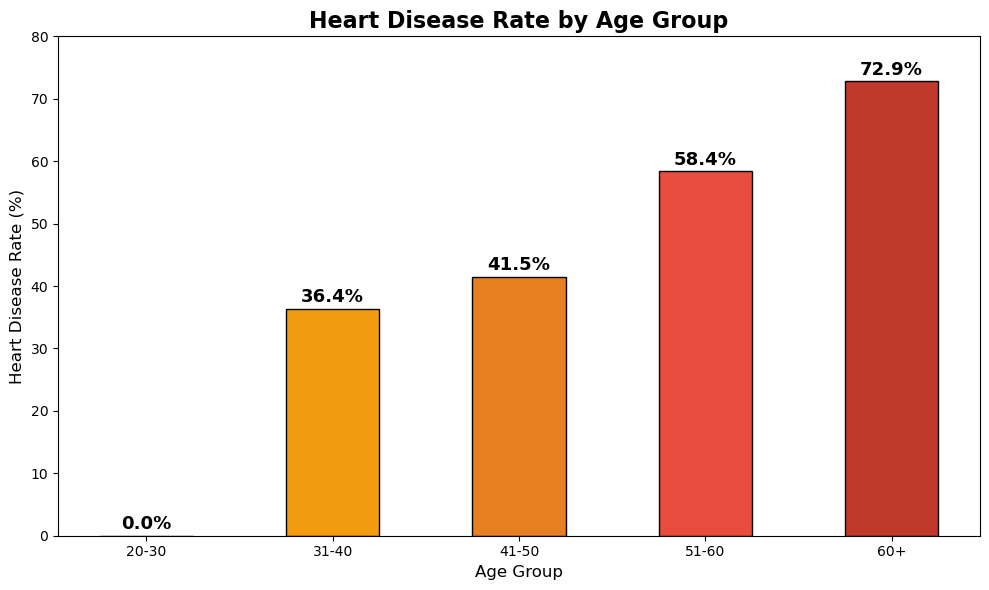

In [23]:
df['AgeGroup'] = pd.cut(df['age'],
                         bins=[20, 30, 40, 50, 60, 80],
                         labels=['20-30', '31-40', '41-50', '51-60', '60+'])

age_group = df.groupby('AgeGroup')['num'].mean() * 100

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C', '#C0392B']
bars = plt.bar(age_group.index, age_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, age_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Age Group',
          fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 80)

plt.tight_layout()
plt.savefig('../plots/hd_02_age_distribution.png', dpi=150)
plt.show()

df = df.drop(columns=['AgeGroup'])

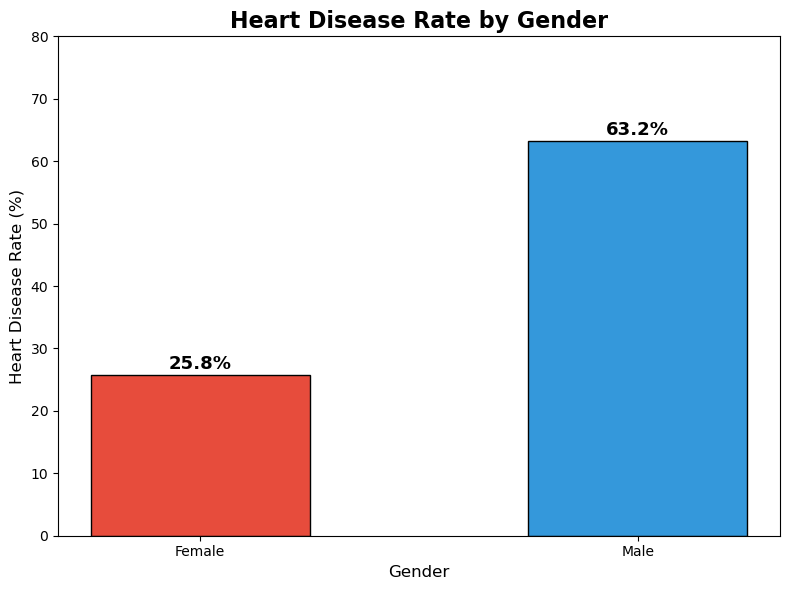

In [21]:
gender_group = df.groupby('sex')['num'].mean() * 100

plt.figure(figsize=(8, 6))
colors = ['#E74C3C', '#3498DB']
bars = plt.bar(['Female', 'Male'], gender_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, gender_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Gender',
          fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 80)

plt.tight_layout()
plt.savefig('../plots/hd_03_gender.png', dpi=150)
plt.show()

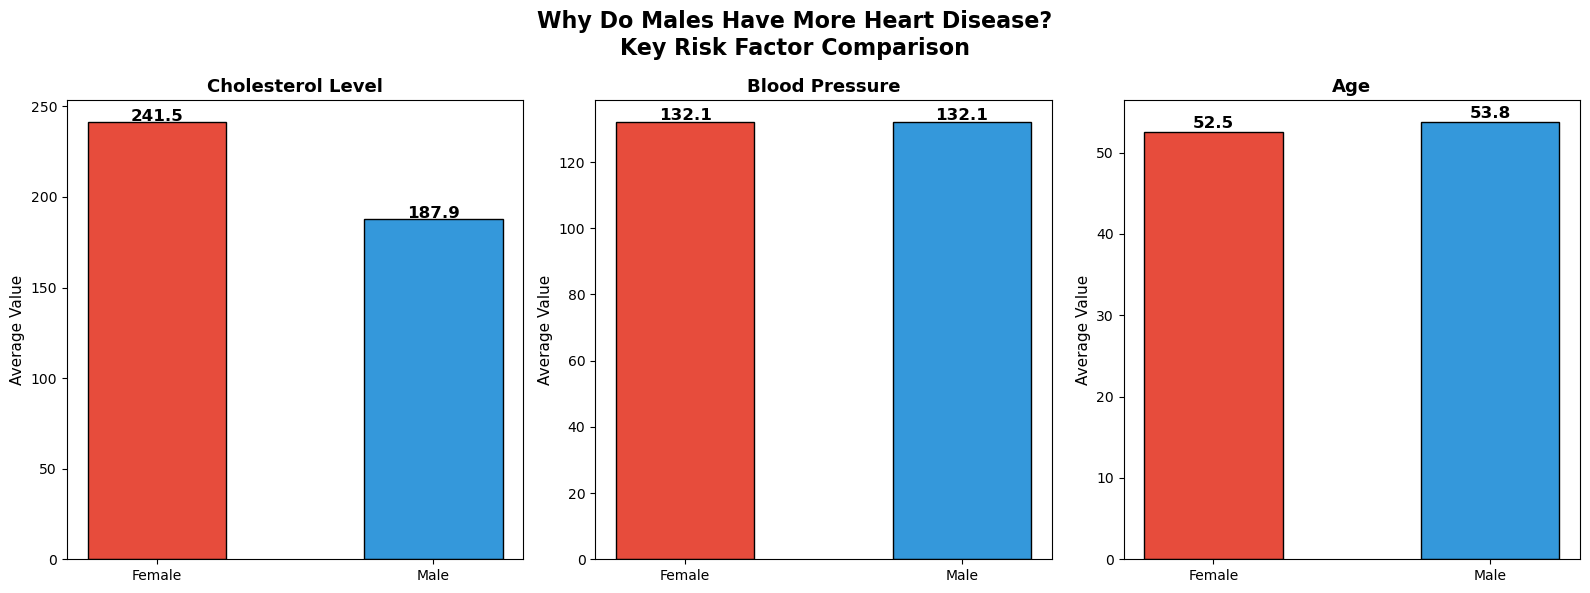

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

factors = ['chol', 'trestbps', 'age']
titles = ['Cholesterol Level', 'Blood Pressure', 'Age']

for i, (factor, title) in enumerate(zip(factors, titles)):
    male = df[df['sex']=='Male'][factor]
    female = df[df['sex']=='Female'][factor]
    
    axes[i].bar(['Female', 'Male'], 
                [female.mean(), male.mean()],
                color=['#E74C3C', '#3498DB'],
                edgecolor='black', width=0.5)
    
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Average Value', fontsize=11)
    
    for j, val in enumerate([female.mean(), male.mean()]):
        axes[i].text(j, val + 0.5, f'{val:.1f}',
                    ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Why Do Males Have More Heart Disease?\nKey Risk Factor Comparison',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/hd_03_gender_factors.png', dpi=150)
plt.show()

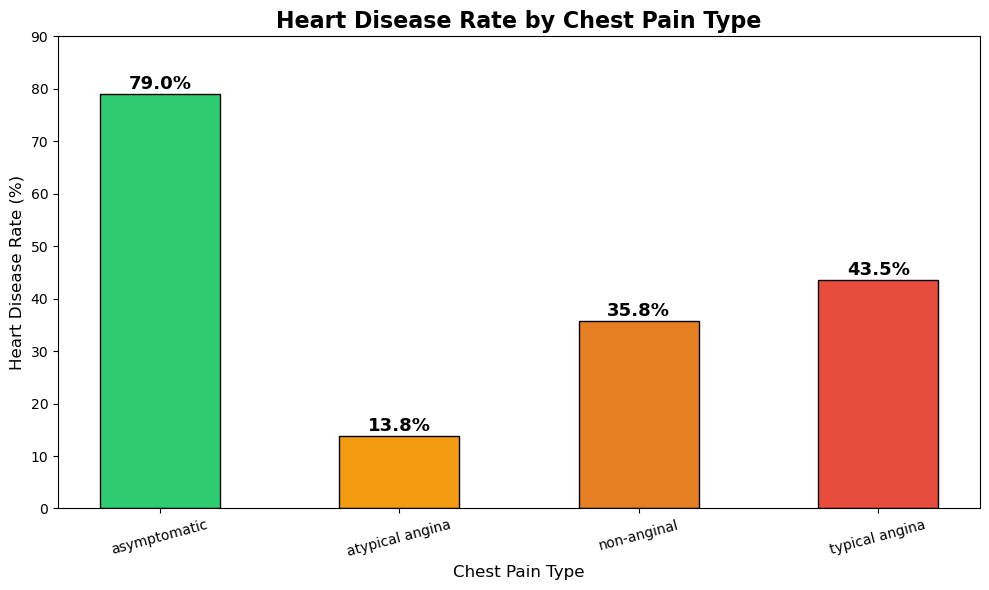

In [23]:
cp_group = df.groupby('cp')['num'].mean() * 100

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars = plt.bar(cp_group.index, cp_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, cp_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Chest Pain Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 90)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../plots/hd_04_chestpain.png', dpi=150)
plt.show()

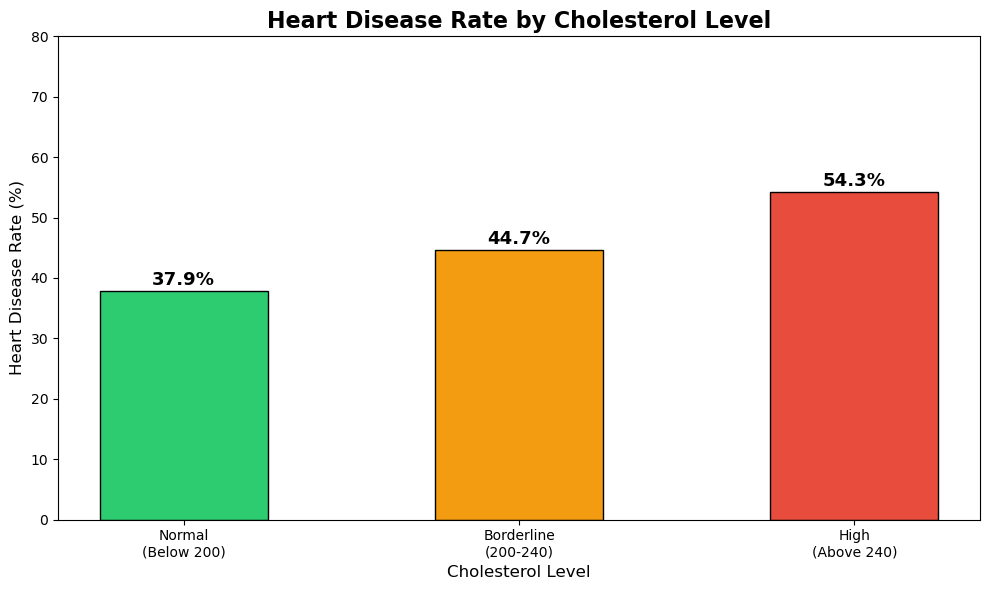

In [25]:
df['CholGroup'] = pd.cut(df['chol'],
                          bins=[0, 200, 240, 600],
                          labels=['Normal\n(Below 200)', 
                                  'Borderline\n(200-240)', 
                                  'High\n(Above 240)'])

chol_group = df.groupby('CholGroup')['num'].mean() * 100

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = plt.bar(chol_group.index, chol_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, chol_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Cholesterol Level',
          fontsize=16, fontweight='bold')
plt.xlabel('Cholesterol Level', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 80)

plt.tight_layout()
plt.savefig('../plots/hd_05_cholesterol.png', dpi=150)
plt.show()

df = df.drop(columns=['CholGroup'])

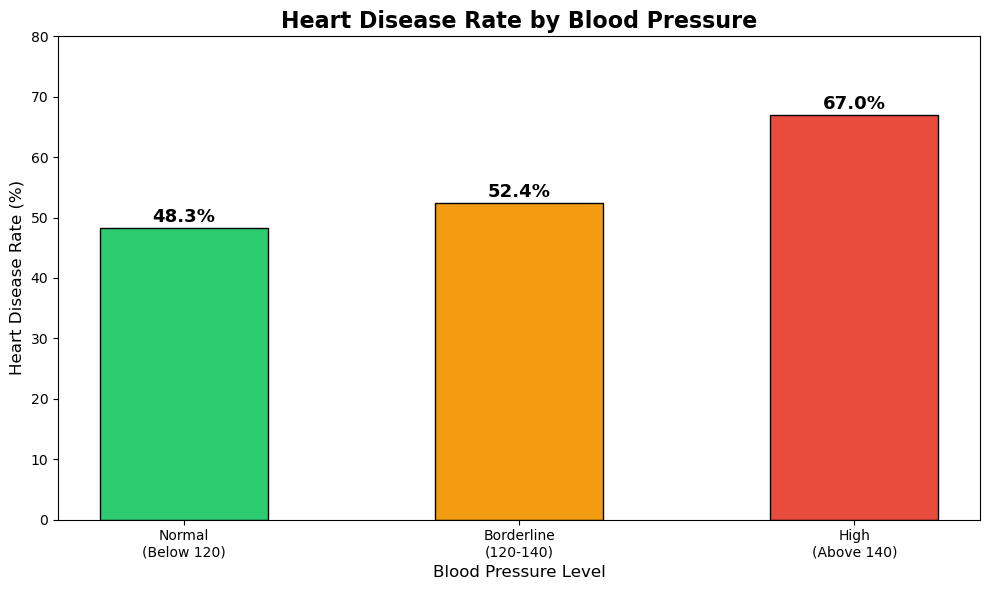

In [26]:
df['BPGroup'] = pd.cut(df['trestbps'],
                        bins=[0, 120, 140, 200],
                        labels=['Normal\n(Below 120)', 
                                'Borderline\n(120-140)', 
                                'High\n(Above 140)'])

bp_group = df.groupby('BPGroup')['num'].mean() * 100

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = plt.bar(bp_group.index, bp_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, bp_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Blood Pressure',
          fontsize=16, fontweight='bold')
plt.xlabel('Blood Pressure Level', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 80)

plt.tight_layout()
plt.savefig('../plots/hd_06_bloodpressure.png', dpi=150)
plt.show()

df = df.drop(columns=['BPGroup'])

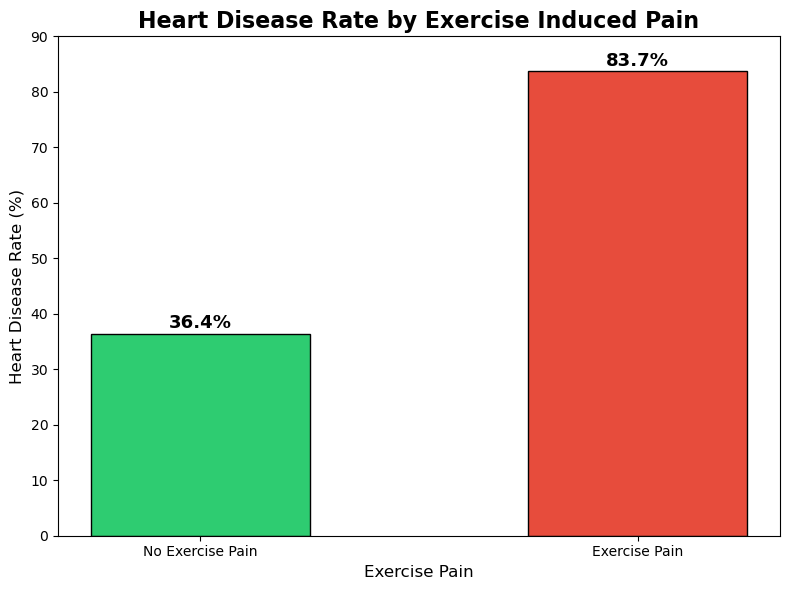

In [27]:
exang_group = df.groupby('exang')['num'].mean() * 100

plt.figure(figsize=(8, 6))
colors = ['#2ECC71', '#E74C3C']
bars = plt.bar(['No Exercise Pain', 'Exercise Pain'],
               exang_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, exang_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Exercise Induced Pain',
          fontsize=16, fontweight='bold')
plt.xlabel('Exercise Pain', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 90)

plt.tight_layout()
plt.savefig('../plots/hd_07_exercise_pain.png', dpi=150)
plt.show()

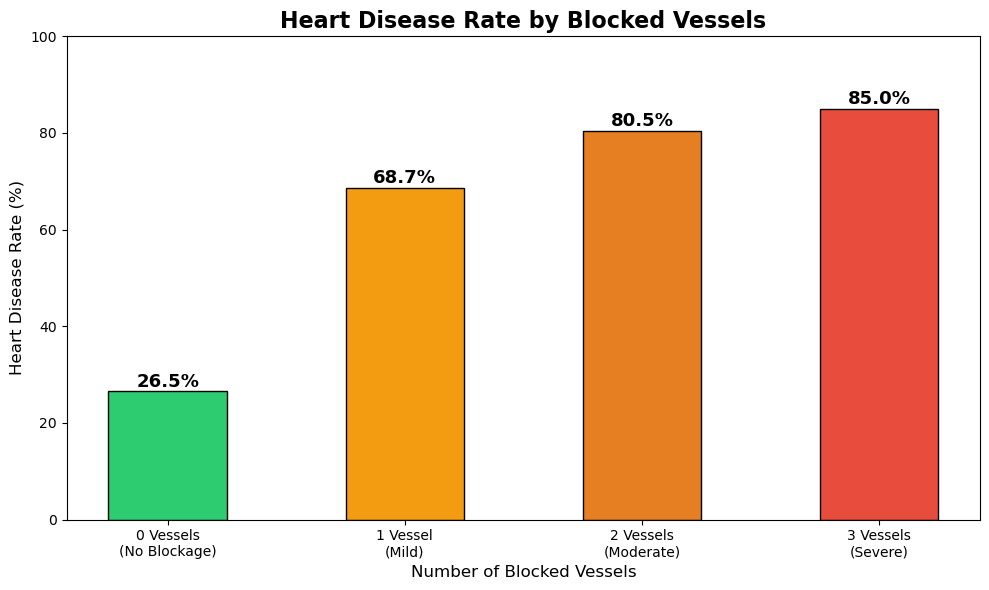

In [28]:
ca_group = df.groupby('ca')['num'].mean() * 100

plt.figure(figsize=(10, 6))
colors = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars = plt.bar(['0 Vessels\n(No Blockage)', '1 Vessel\n(Mild)', 
                '2 Vessels\n(Moderate)', '3 Vessels\n(Severe)'],
               ca_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, ca_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Heart Disease Rate by Blocked Vessels',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Blocked Vessels', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('../plots/hd_08_blocked_vessels.png', dpi=150)
plt.show()

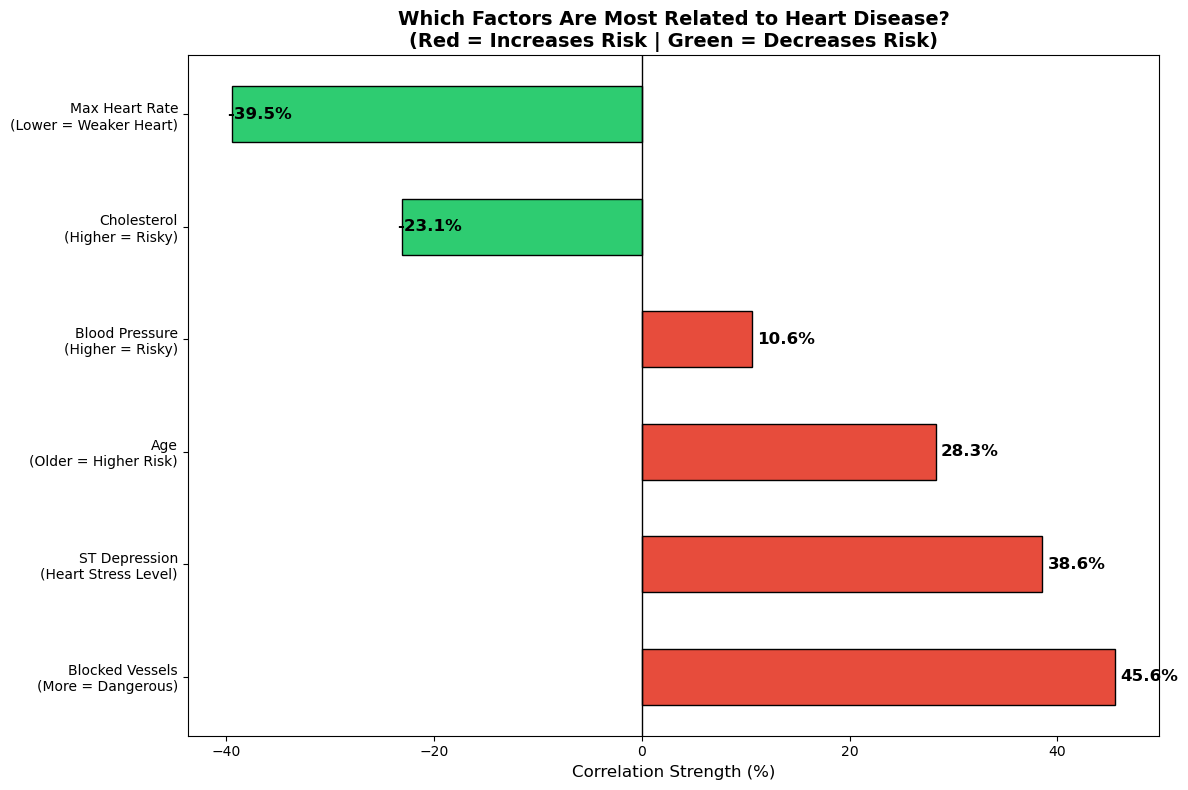

In [33]:
df_orig = pd.read_csv('../data/heart_disease_uci.csv')
df_orig['num'] = df_orig['num'].apply(lambda x: 1 if x > 0 else 0)

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
corr = df_orig[numeric_cols].corr()['num'].drop('num').sort_values(ascending=False)

# Rename with descriptions
labels = {
    'ca': 'Blocked Vessels\n(More = Dangerous)',
    'oldpeak': 'ST Depression\n(Heart Stress Level)',
    'age': 'Age\n(Older = Higher Risk)',
    'trestbps': 'Blood Pressure\n(Higher = Risky)',
    'chol': 'Cholesterol\n(Higher = Risky)',
    'thalch': 'Max Heart Rate\n(Lower = Weaker Heart)'
}

corr.index = [labels[i] for i in corr.index]

plt.figure(figsize=(12, 8))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in corr.values]

bars = plt.barh(corr.index, corr.values * 100,
                color=colors, edgecolor='black', height=0.5)

for bar, val in zip(bars, corr.values * 100):
    plt.text(val + 0.5 if val > 0 else val - 0.5,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center',
             fontsize=12, fontweight='bold')

plt.axvline(0, color='black', linewidth=1)
plt.title('Which Factors Are Most Related to Heart Disease?\n(Red = Increases Risk | Green = Decreases Risk)',
          fontsize=14, fontweight='bold')
plt.xlabel('Correlation Strength (%)', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/hd_09_correlation.png', dpi=150)
plt.show()

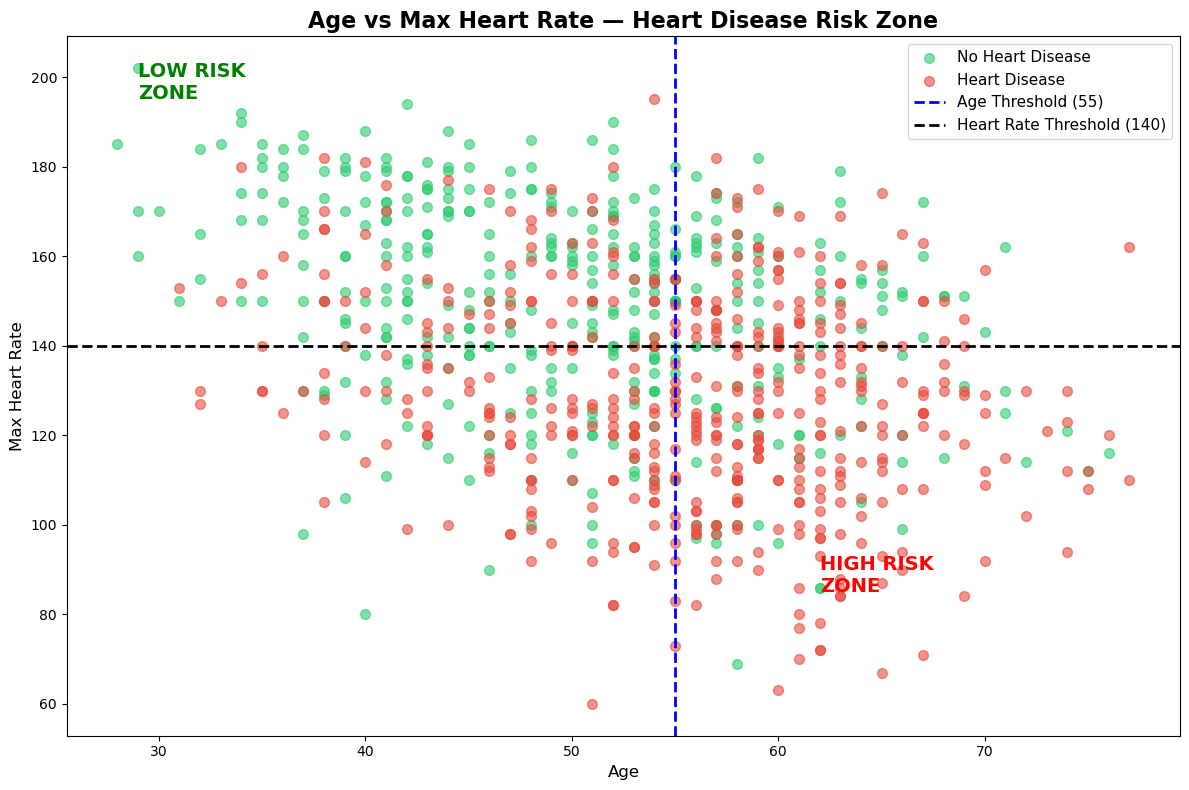

In [35]:
plt.figure(figsize=(12, 8))

no_disease = df[df['num'] == 0]
disease = df[df['num'] == 1]

plt.scatter(no_disease['age'], no_disease['thalch'],
            color='#2ECC71', alpha=0.6, 
            label='No Heart Disease', s=50)
plt.scatter(disease['age'], disease['thalch'],
            color='#E74C3C', alpha=0.6, 
            label='Heart Disease', s=50)

plt.axvline(55, color='blue', linestyle='--', 
            linewidth=2, label='Age Threshold (55)')
plt.axhline(140, color='black', linestyle='--', 
            linewidth=2, label='Heart Rate Threshold (140)')

# Fixed zone labels
plt.text(62, 85, 'HIGH RISK\nZONE', fontsize=14,
         color='red', fontweight='bold')
plt.text(29, 195, 'LOW RISK\nZONE', fontsize=14,
         color='green', fontweight='bold')

plt.title('Age vs Max Heart Rate — Heart Disease Risk Zone',
          fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Max Heart Rate', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/hd_10_risk_zone.png', dpi=150)
plt.show()

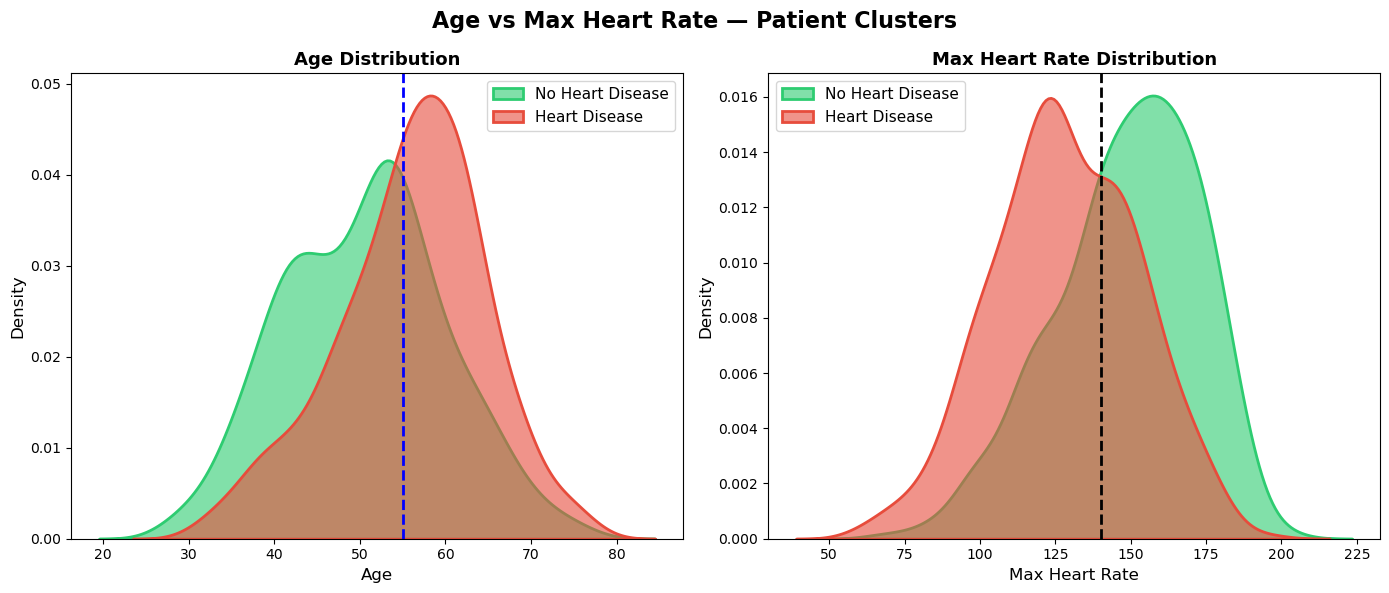

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

no_disease = df[df['num'] == 0]
disease = df[df['num'] == 1]

# Age KDE
sns.kdeplot(no_disease['age'], fill=True, color='#2ECC71',
            label='No Heart Disease', alpha=0.6, linewidth=2, ax=axes[0])
sns.kdeplot(disease['age'], fill=True, color='#E74C3C',
            label='Heart Disease', alpha=0.6, linewidth=2, ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].axvline(55, color='blue', linestyle='--', linewidth=2, label='Age 55')

# Max Heart Rate KDE
sns.kdeplot(no_disease['thalch'], fill=True, color='#2ECC71',
            label='No Heart Disease', alpha=0.6, linewidth=2, ax=axes[1])
sns.kdeplot(disease['thalch'], fill=True, color='#E74C3C',
            label='Heart Disease', alpha=0.6, linewidth=2, ax=axes[1])
axes[1].set_title('Max Heart Rate Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Heart Rate', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].axvline(140, color='black', linestyle='--', linewidth=2)

plt.suptitle('Age vs Max Heart Rate — Patient Clusters',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/hd_10_kde.png', dpi=150)
plt.show()

In [14]:
df = pd.read_csv('../data/heart_clean.csv')

print("Shape:", df.shape)
print("\nTarget Distribution:")
print(df['num'].value_counts())

Shape: (920, 23)

Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [15]:
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nClass Distribution in Training:")
print(y_train.value_counts())

Training samples: 736
Testing samples: 184

Class Distribution in Training:
num
1    400
0    336
Name: count, dtype: int64


In [17]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pickle

import warnings
warnings.filterwarnings('ignore')

In [18]:
xgb_heart = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss'
)

xgb_heart.fit(X_train, y_train)

y_pred = xgb_heart.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Heart Disease', 'Heart Disease']))

Accuracy: 92.93%

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.87      0.97      0.92        75
   Heart Disease       0.98      0.90      0.94       109

        accuracy                           0.93       184
       macro avg       0.92      0.94      0.93       184
    weighted avg       0.93      0.93      0.93       184



In [21]:
def predict_heart_disease(patient_data):
    
    sample_df = pd.DataFrame([patient_data])
    prediction = xgb_heart.predict(sample_df)[0]
    probability = xgb_heart.predict_proba(sample_df)[0]
    confidence = probability[prediction] * 100
    
    heart_info = {
        0: {
            'name': 'No Heart Disease',
            'risk': 'Low',
            'description': 'Your heart appears to be healthy based on the data provided.',
            'action': 'Maintain your healthy lifestyle and get regular checkups.',
            'diet': 'Continue eating a balanced diet with fruits and vegetables.',
            'exercise': 'Keep up your current physical activity level.'
        },
        1: {
            'name': 'Heart Disease Detected',
            'risk': 'High',
            'description': 'Signs of heart disease detected. Immediate attention required!',
            'action': 'See a cardiologist immediately! Do not delay treatment.',
            'diet': 'Avoid fatty foods, salt and processed foods immediately.',
            'exercise': 'Light walking only — no strenuous exercise until cleared by doctor.'
        }
    }
    
    info = heart_info[prediction]
    
    print("=" * 55)
    print("      MEDIRISK — HEART DISEASE PREDICTION REPORT")
    print("=" * 55)
    print(f"\nDiagnosis    : {info['name']}")
    print(f"Confidence   : {confidence:.1f}%")
    print(f"Risk Level   : {info['risk']}")
    print(f"\nWhat it means: {info['description']}")
    print(f"\nAction needed: {info['action']}")
    print(f"\nDiet advice  : {info['diet']}")
    print(f"\nExercise     : {info['exercise']}")
    print("\n⚠️  This is not a substitute for professional medical advice!")
    print("=" * 55)

In [22]:
import pickle

with open('../models/heart_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_heart, f)

print("Heart Disease model saved successfully!")

Heart Disease model saved successfully!


In [23]:
sample_heart_patient = {
    'age': 63,
    'sex': 1,              # Male
    'trestbps': 145,       # High BP
    'chol': 280,           # High Cholesterol
    'fbs': 1,              # High Blood Sugar
    'thalch': 100,         # Low Max Heart Rate
    'exang': 1,            # Exercise Pain
    'oldpeak': 2.5,        # High ST Depression
    'ca': 2,               # 2 Blocked Vessels
    'cp_asymptomatic': 1,
    'cp_atypical angina': 0,
    'cp_non-anginal': 0,
    'cp_typical angina': 0,
    'restecg_lv hypertrophy': 1,
    'restecg_normal': 0,
    'restecg_st-t abnormality': 0,
    'slope_downsloping': 1,
    'slope_flat': 0,
    'slope_upsloping': 0,
    'thal_fixed defect': 1,
    'thal_normal': 0,
    'thal_reversable defect': 0
}

predict_heart_disease(sample_heart_patient)

      MEDIRISK — HEART DISEASE PREDICTION REPORT

Diagnosis    : Heart Disease Detected
Confidence   : 99.9%
Risk Level   : High

What it means: Signs of heart disease detected. Immediate attention required!

Action needed: See a cardiologist immediately! Do not delay treatment.

Diet advice  : Avoid fatty foods, salt and processed foods immediately.

Exercise     : Light walking only — no strenuous exercise until cleared by doctor.

⚠️  This is not a substitute for professional medical advice!


In [24]:
healthy_heart_patient = {
    'age': 35,
    'sex': 0,              # Female
    'trestbps': 115,       # Normal BP
    'chol': 180,           # Normal Cholesterol
    'fbs': 0,              # Normal Blood Sugar
    'thalch': 175,         # High Max Heart Rate
    'exang': 0,            # No Exercise Pain
    'oldpeak': 0.0,        # No ST Depression
    'ca': 0,               # No Blocked Vessels
    'cp_asymptomatic': 0,
    'cp_atypical angina': 1,
    'cp_non-anginal': 0,
    'cp_typical angina': 0,
    'restecg_lv hypertrophy': 0,
    'restecg_normal': 1,
    'restecg_st-t abnormality': 0,
    'slope_downsloping': 0,
    'slope_flat': 0,
    'slope_upsloping': 1,
    'thal_fixed defect': 0,
    'thal_normal': 1,
    'thal_reversable defect': 0
}

predict_heart_disease(healthy_heart_patient)

      MEDIRISK — HEART DISEASE PREDICTION REPORT

Diagnosis    : No Heart Disease
Confidence   : 99.7%
Risk Level   : Low

What it means: Your heart appears to be healthy based on the data provided.

Action needed: Maintain your healthy lifestyle and get regular checkups.

Diet advice  : Continue eating a balanced diet with fruits and vegetables.

Exercise     : Keep up your current physical activity level.

⚠️  This is not a substitute for professional medical advice!
